In [9]:
# --- 1. Import Libraries & Mount Drive ---
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [10]:
# Mount Google Drive
try:
    drive.mount('/content/drive')
    print("Google Drive mounted successfully!")
except:
    print("Error mounting Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully!


In [11]:
# --- 2. Data Preparation ---
print("\n--- 2. Data Preparation ---")
try:
    file_path = '/content/drive/MyDrive/AI_ML/Outputs/final.csv'
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print(f"ERROR: File not found at '{file_path}'. Please check the path.")
    exit()


--- 2. Data Preparation ---
Dataset loaded successfully!


In [12]:
# Map quality to binary class
def map_quality_to_class(quality):
    if quality in [3, 4, 5]: return 0  # Bad
    elif quality in [6, 7, 8]: return 1  # Good
    return -1

df['quality_class'] = df['quality'].apply(map_quality_to_class)
X = df.drop(['quality', 'quality_class'], axis=1)
y = df['quality_class']

In [13]:
# Split data ONCE for all models
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Data split: {len(X_train)} training samples, {len(X_test)} test samples.")

Data split: 908 training samples, 227 test samples.


In [14]:
# --- 3. Making the Baseline Model ---
print("\n--- 3. Training Baseline Model ---")
baseline_model = RandomForestClassifier(n_estimators=100, random_state=42)
baseline_model.fit(X_train, y_train)


--- 3. Training Baseline Model ---


RandomForestClassifier(random_state=42)

In [15]:
# Evaluate baseline model
y_pred_baseline = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
print(f"Baseline Model Test Accuracy: {baseline_accuracy:.4f}")

Baseline Model Test Accuracy: 0.7974


In [16]:
# --- 4. Hyperparameter Tuning Steps (Setup) ---
print("\n--- 4. Setting up Hyperparameter Tuning ---")
# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}


--- 4. Setting up Hyperparameter Tuning ---


In [17]:
# Initialize the base estimator
rf_estimator = RandomForestClassifier(random_state=42)

In [18]:
# Initialize GridSearchCV
# cv=5 for 5-fold cross-validation
# n_jobs=-1 uses all available CPU cores
grid_search = GridSearchCV(estimator=rf_estimator,
                           param_grid=param_grid,
                           cv=5,
                           n_jobs=-1,
                           scoring='accuracy',
                           verbose=2)

print("GridSearchCV configured. Ready to run tuning.")

GridSearchCV configured. Ready to run tuning.


In [19]:
# --- 5. Running the Hyperparameter Tuning ---
print("\n--- 5. Starting Hyperparameter Tuning... (This may take a few minutes) ---")
grid_search.fit(X_train, y_train)
print("Tuning complete!")


--- 5. Starting Hyperparameter Tuning... (This may take a few minutes) ---
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Tuning complete!


In [20]:
# --- 6. Evaluating the Tuned Model (Hyperparameter Tuning After Model) ---
print("\n--- 6. Evaluating the Tuned Model ---")
# Get the best model found by GridSearchCV
tuned_model = grid_search.best_estimator_

print(f"Best Parameters found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy (from tuning): {grid_search.best_score_:.4f}")


--- 6. Evaluating the Tuned Model ---
Best Parameters found: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validation accuracy (from tuning): 0.7764


In [21]:
# Evaluate the tuned model on the *test set*
y_pred_tuned = tuned_model.predict(X_test)
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
print(f"Tuned Model Test Accuracy: {tuned_accuracy:.4f}")

Tuned Model Test Accuracy: 0.8194


In [22]:
# --- 7. Baseline and Tuned Model Comparison ---
print("\n--- 7. Model Comparison ---")
print("                          Baseline   |   Tuned")
print("---------------------------------------------------")
print(f"Test Set Accuracy:        {baseline_accuracy:<10.4f} |   {tuned_accuracy:<10.4f}")
print(f"Improvement:              {tuned_accuracy - baseline_accuracy:+.4f}")

print("\n--- Baseline Model Report ---")
print(classification_report(y_test, y_pred_baseline, target_names=['Bad (Class 0)', 'Good (Class 1)']))

print("\n--- Tuned Model Report ---")
print(classification_report(y_test, y_pred_tuned, target_names=['Bad (Class 0)', 'Good (Class 1)']))


--- 7. Model Comparison ---
                          Baseline   |   Tuned
---------------------------------------------------
Test Set Accuracy:        0.7974     |   0.8194    
Improvement:              +0.0220

--- Baseline Model Report ---
                precision    recall  f1-score   support

 Bad (Class 0)       0.78      0.79      0.78       105
Good (Class 1)       0.82      0.80      0.81       122

      accuracy                           0.80       227
     macro avg       0.80      0.80      0.80       227
  weighted avg       0.80      0.80      0.80       227


--- Tuned Model Report ---
                precision    recall  f1-score   support

 Bad (Class 0)       0.80      0.81      0.81       105
Good (Class 1)       0.83      0.83      0.83       122

      accuracy                           0.82       227
     macro avg       0.82      0.82      0.82       227
  weighted avg       0.82      0.82      0.82       227




--- 8. Generating Comparison Graphs ---


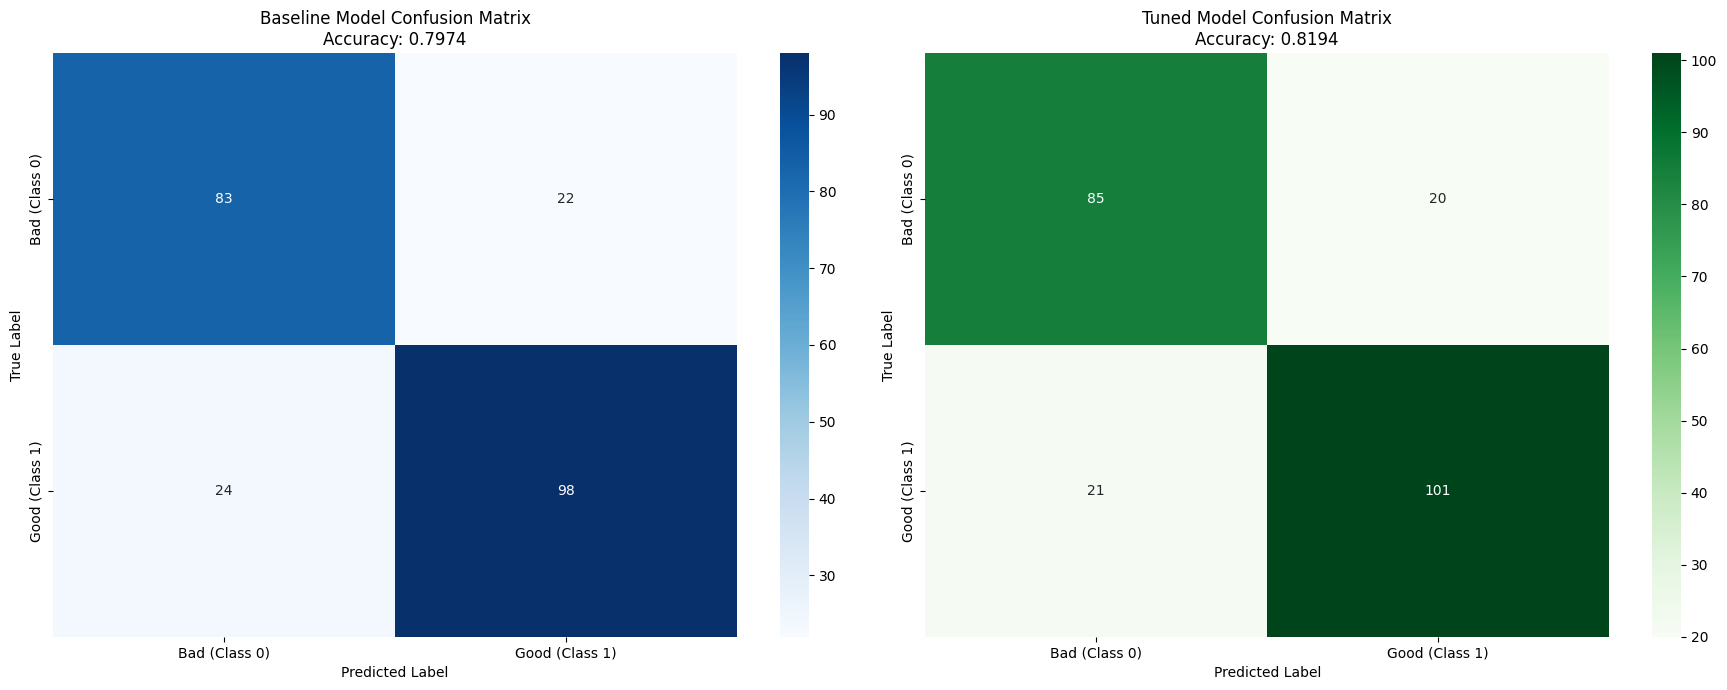

In [23]:
# --- 8. Graph (Comparative Confusion Matrices) ---
print("\n--- 8. Generating Comparison Graphs ---")
cm_baseline = confusion_matrix(y_test, y_pred_baseline)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
target_names = ['Bad (Class 0)', 'Good (Class 1)']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names, ax=ax1)
ax1.set_title(f'Baseline Model Confusion Matrix\nAccuracy: {baseline_accuracy:.4f}')
ax1.set_xlabel('Predicted Label')
ax1.set_ylabel('True Label')

sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names, ax=ax2)
ax2.set_title(f'Tuned Model Confusion Matrix\nAccuracy: {tuned_accuracy:.4f}')
ax2.set_xlabel('Predicted Label')
ax2.set_ylabel('True Label')

plt.tight_layout()
plt.show()

In [24]:
# --- 9. Prediction on New Data ---
print("\n--- 9. Example Prediction on New Data ---")
# Using the first 5 rows of the test set as "new" unseen data
new_data_samples = X_test.head()

print("Predicting on 5 new samples:")
print(new_data_samples)

# Use the *tuned_model* for final predictions
new_predictions = tuned_model.predict(new_data_samples)
new_probabilities = tuned_model.predict_proba(new_data_samples)

print("\nPredicted Classes (0=Bad, 1=Good):")
print(new_predictions)

print("\nPrediction Probabilities ([Prob of 0, Prob of 1]):")
print(np.round(new_probabilities, 3))

print("\nActual Classes (for comparison):")
print(y_test.head().values)


--- 9. Example Prediction on New Data ---
Predicting on 5 new samples:
          PC_1      PC_2      PC_3      PC_4      PC_5      PC_6
222   2.669496 -2.343799  2.202143  0.187725 -0.081729 -0.904051
487   4.275467 -2.605757  1.356476 -0.787925 -0.998704  0.551440
475  -3.203499 -0.687449  1.444506  3.064922 -2.457240 -0.550785
1072 -1.497701 -0.148615  1.515923 -0.996947 -0.475392  0.334924
606   0.282796  2.436376  1.780021  0.767036 -0.547743  0.673099

Predicted Classes (0=Bad, 1=Good):
[0 0 1 0 1]

Prediction Probabilities ([Prob of 0, Prob of 1]):
[[0.676 0.324]
 [0.854 0.146]
 [0.362 0.638]
 [0.504 0.496]
 [0.006 0.994]]

Actual Classes (for comparison):
[1 0 1 0 1]
